FIFA World Cup Historical Analysis (1930–2022)
Exploring 90 years of data ahead of the 2026 tournament

This notebook analyzes historical FIFA World Cup match data to uncover patterns in team performance, home advantage, goal scoring trends, and stage dominance. The findings provide context for what we might expect at the 2026 World Cup.

In [86]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
plt.rcParams["figure.figsize"] = (10, 6)
df1 = pd.read_csv ('2022_world_cup_matches1.csv')

df2 = pd.read_csv ('international_matches1.csv')

df3 = pd.read_csv ('world_cup_matches1.csv')

df4 = pd.read_csv ('world_cups1.csv')

This snippet of code below was the first step in identifying any null spaces present within the dataset. Thus, the total entries matched the Non-Null Count for each column, which showed that the data was already cleaned!

In [87]:
# understand structural health of each df
df1.info()
df2.info()
df3.info()
df4.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64 entries, 0 to 63
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   ID         64 non-null     int64 
 1   Year       64 non-null     int64 
 2   Stage      64 non-null     object
 3   Home Team  64 non-null     object
 4   Away Team  64 non-null     object
dtypes: int64(2), object(3)
memory usage: 2.6+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17769 entries, 0 to 17768
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   ID                   17769 non-null  int64 
 1   Tournament           17769 non-null  object
 2   Date                 17769 non-null  object
 3   Home Team            17769 non-null  object
 4   Away Team            17769 non-null  object
 5   Home Goals           17769 non-null  int64 
 6   Away Goals           17769 non-null  int64 
 7   Home Stadium or Not  

1. Which teams have the best historical win rates?
We start by determining a win rate for every team that has appeared in a World Cup, then identify the top 15 most successful teams historically.

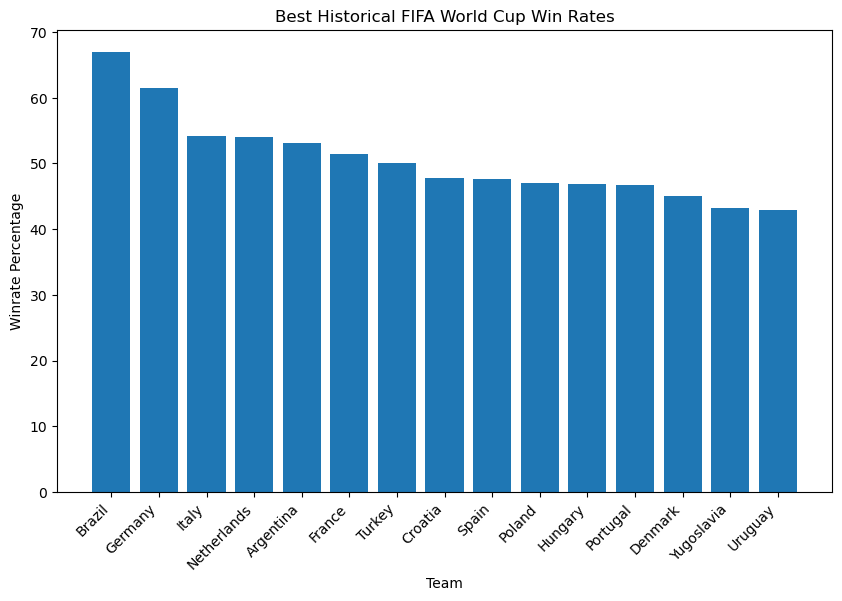

In [88]:
# Calculating match results
hg = df3['Home Goals']
ht = df3['Home Team']
ag = df3['Away Goals']
at = df3['Away Team']

conditions = [
    (hg > ag), 
    (ag > hg), 
    (ag == hg),
]

choices = [ht, at, "Tie game, no winner."]

# Creates a winner column in df3 based on the home vs away goals
df3["Winner"] = np.select (conditions, choices, default="Tie game, no winner.")

# Determining win count per team
wins = df3.groupby("Winner")["ID"].count()

# Determining total games played per team
# Since a team can appear in both home and away team columns, count both
homeappearances = df3.groupby("Home Team")["ID"].count()
awayappearances = df3.groupby("Away Team")["ID"].count()

totalgames = homeappearances + awayappearances

# Calculating winrate 
winrate = wins / totalgames * 100

# Correctly treating any NaN values
winrate = winrate.fillna(0)

# Sorting winrate in descending order
winrate = winrate.sort_values(ascending=False)

# Taking only top 15
winrate = winrate.head(15)

# Creating bar chart 
plt.bar(winrate.index, winrate.values)
plt.title("Best Historical FIFA World Cup Win Rates")
plt.ylabel("Winrate Percentage")
plt.xlabel("Team")
plt.xticks(rotation=45, ha='right')
plt.show()


2. Does hosting give a real advantage?
Here we compare the win rate of host nations against non-host teams to determine whether playing on home soil provides a meaningful boost.

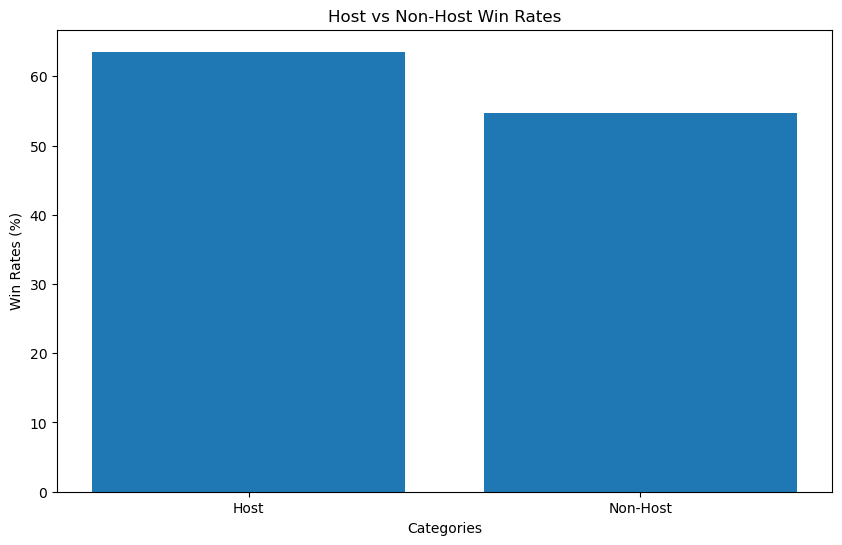

In [89]:

# Comparing host vs non-host performance
htn = df3['Host Team or Not']
df3filtered = df3.loc[htn==1]

# Calculating win rate for hosts
hostwinrate = df3filtered.loc[df3filtered["Winner"]==df3filtered["Home Team"]]
hostwinrate = len(hostwinrate) / 118 * 100

# Calculating win rate for non-hosts
df3filteredagain = df3.loc[htn==0]
non_hostwinrate = df3filteredagain.loc[df3filteredagain["Winner"] == df3filteredagain["Home Team"]]
non_hostwinrate = len(non_hostwinrate) / len(df3filteredagain) * 100

# Creating bar chart
categories = ['Host', 'Non-Host']
win_rates = [hostwinrate, non_hostwinrate]
plt.figure()
plt.bar(categories, win_rates)
plt.title("Host vs Non-Host Win Rates")
plt.ylabel("Win Rates (%)")
plt.xlabel("Categories")
plt.show()

3. Which stages see the most goals?
We examine whether matches become more or less open as the tournament progresses by comparing average goals per match at each stage.

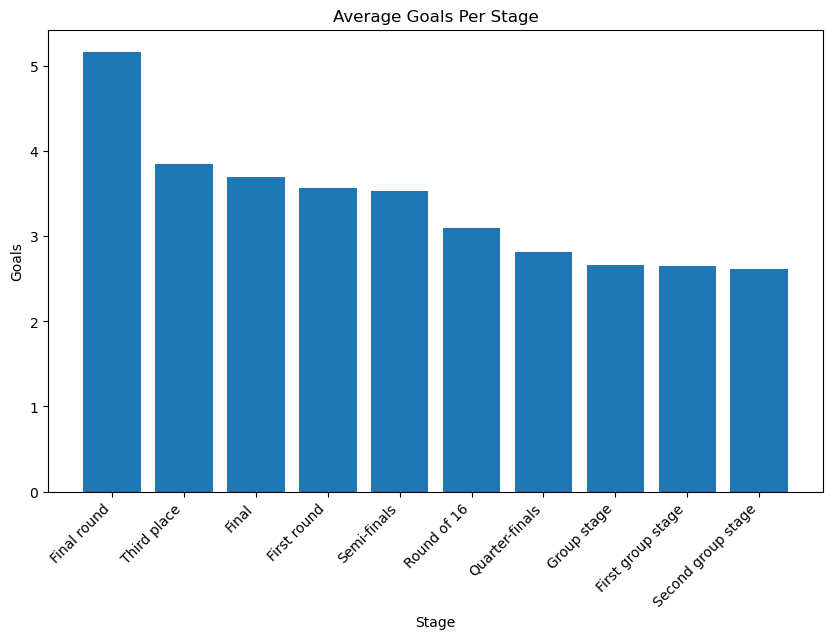

In [90]:
# Calculating total goals per match
df3["Total Goals"] = df3["Home Goals"] + df3["Away Goals"]

# Determining average goals per match for each stage
dfbystage = df3.groupby("Stage")["Total Goals"].mean()

# Sorting by descending order
dfbystage = dfbystage.sort_values(ascending=False)

# Creating bar chart
plt.figure()
plt.bar(dfbystage.index, dfbystage.values)
plt.title("Average Goals Per Stage")
plt.ylabel("Goals")
plt.xlabel("Stage")
plt.xticks(rotation=45, ha='right')
plt.show()

4. Goal scoring trends across decades
Has football become more or less attacking over time? We look at average goals per match by decade from the 1930s to the 2010s.

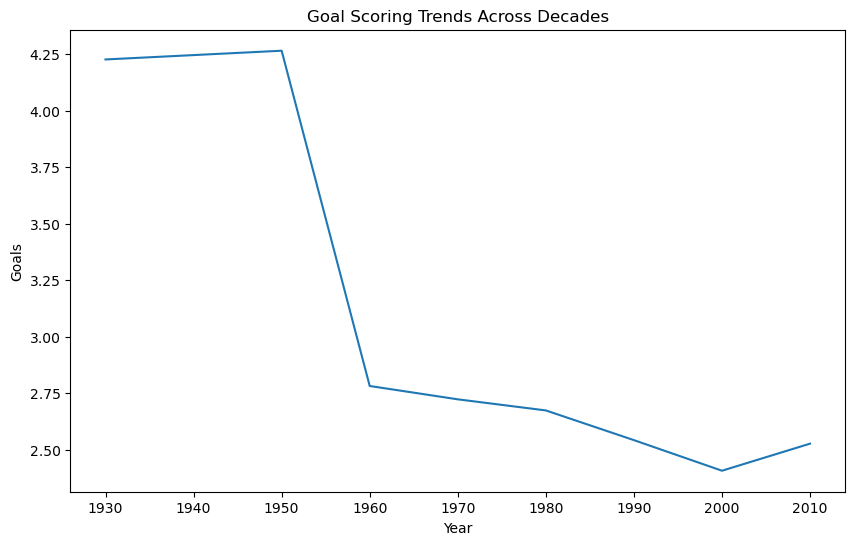

In [91]:
# Converting years into decades
df3["Decade"] = (df3["Year"] // 10 * 10)

# Determining average goals per match per decade
dfbydecade = df3.groupby("Decade")["Total Goals"].mean()

# Creating line chart
plt.figure()
plt.plot(dfbydecade.index, dfbydecade.values)
plt.title("Goal Scoring Trends Across Decades")
plt.ylabel("Goals")
plt.xlabel("Year")
plt.show()

5. Most dominant teams in group stage vs knockout rounds
Some teams dominate in the group stage but struggle when it matters most. Here we compare the top teams in each phase of the tournament.

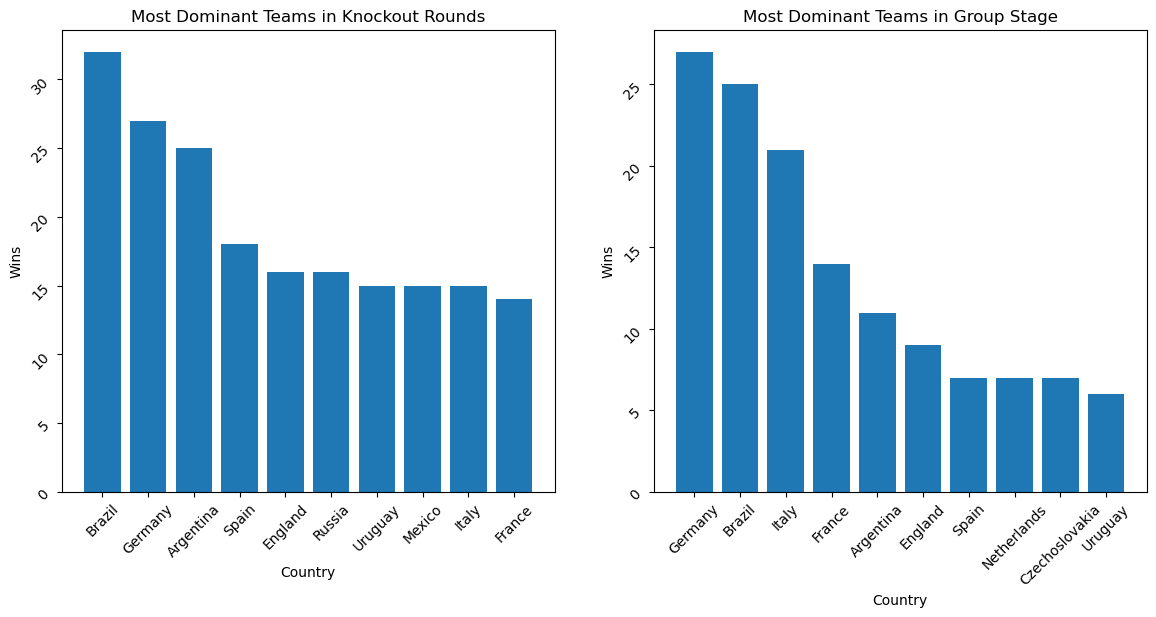

In [92]:
# Splitting df3 into 2 groups
df3group1 = df3.loc[df3['Stage'] == 'Group stage']
df3group2 = df3.loc[df3['Stage'].isin (['Semi-finals', 'Final', 'Round of 16', 'Quarter-finals'])]

# Calculating which teams won the most matches
dfteamwon1 = df3group1.groupby("Winner") ["ID"].count()
dfteamwon2 = df3group2.groupby("Winner") ["ID"].count()

# Filtering out Tie
dfteamwon1 = dfteamwon1[dfteamwon1.index != "Tie game, no winner."]
dfteamwon2 = dfteamwon2[dfteamwon2.index != "Tie game, no winner."]

# Sort in descending order
dfteamwon1 = dfteamwon1.sort_values(ascending=False)
dfteamwon2 = dfteamwon2.sort_values(ascending=False)

# Take top 10 from each
dfteamwon1 = dfteamwon1.head(10)
dfteamwon2 = dfteamwon2.head(10)

# Creating two bar charts side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

ax1.bar(dfteamwon1.index, dfteamwon1.values)
ax1.set_title("Most Dominant Teams in Knockout Rounds")
ax1.set_ylabel("Wins")
ax1.set_xlabel("Country")
ax1.tick_params(rotation=45)

ax2.bar(dfteamwon2.index, dfteamwon2.values)
ax2.set_title("Most Dominant Teams in Group Stage")
ax2.set_ylabel("Wins")
ax2.set_xlabel("Country")
ax2.tick_params(rotation=45)

Conclusion

Across 90 years of World Cup data, a few clear patterns emerge. Brazil and Germany are historically the most dominant teams. Host nations win roughly 9% more often than non-hosts which is a significant advantage heading into 2026 with the USA, Canada, and Mexico co-hosting. Goal scoring has declined steadily since the 1950s, suggesting modern football is more tactically defensive. Finally, the teams that dominate group stages largely carry that form into knockouts, though the margins tighten considerably.